# Steps Predictor — GBT + SHAP Feature Importance

**Research question:** What explains day-to-day variation in physical activity (daily steps)?  
Do external factors (weather, air quality, holidays, COVID stringency) contribute meaningfully beyond a patient's own physiology history?

**Approach:**
- Target: `daily_steps` (today's step count)
- Features: hand-picked 37 features — yesterday's physiology, last-week physiology (rolling), today's external context, study metadata
- Models: LightGBM vs CatBoost (pick winner by CV R²)
- Validation: `TimeSeriesSplit(n_splits=5)` (temporal) + `GroupKFold(n_splits=5)` (patient)
- Interpretation: SHAP beeswarm + feature-group importance bar + dependence plots

In [55]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import shap
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..') if os.getcwd().endswith('notebooks') else os.getcwd()
)
sys.path.insert(0, PROJECT_ROOT)
import data_prep as dp

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
EXT_DIR  = os.path.join(DATA_DIR, 'external')
FIG_DIR  = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_SEED = 42
TARGET      = 'daily_steps'

DISEASE_ORDER   = ['Early Disease Stage', 'Fast Disease Progression', 'Late Disease Stage']
WEATHER_ORDER   = ['Rainy', 'Drizzly', 'Cloudy', 'Partly cloudy', 'Sunny', 'Hot & sunny']

print('Setup complete.')

Setup complete.


## Section 1 — Data Loading

In [2]:
import glob

# ── Sensor data ───────────────────────────────────────────────────────────────
files  = glob.glob(os.path.join(DATA_DIR, 'Hourly Sensor Data', 'RHourly_*.csv'))
chunks = []
for fp in files:
    pid = int(os.path.basename(fp).replace('RHourly_', '').replace('.csv', ''))
    c = pd.read_csv(fp); c['id'] = pid; chunks.append(c)
sensor = pd.concat(chunks, ignore_index=True)
sensor['time']      = pd.to_datetime(sensor['time'])
sensor['heartrate'] = pd.to_numeric(sensor['heartrate'], errors='coerce')

# ── Clinical markers ─────────────────────────────────────────────────────────
clinical = pd.read_csv(os.path.join(DATA_DIR, 'ClinicalMarkers_final.csv'))
clinical.columns = clinical.columns.str.strip().str.lower().str.replace('.', '_', regex=False)
clinical['disease_type'] = clinical['disease_type'].str.strip()
df_merged = clinical[['id', 'age', 'sex', 'disease_type']].merge(sensor, on='id', how='left')

# ── Complete patient-days + daily aggregation ────────────────────────────────
# let's see all data first --> complete=False
df    = dp.get_complete_patient_days(df_merged, sleep_shift_hour=6, complete=False)

daily = dp.aggregate_to_daily(df)

# Drop device-not-worn days (no sleep signal)
daily = daily[daily['sum_sleep_minute'] > 0].copy()

print(f'Daily rows: {len(daily):,}  |  patients: {daily["id"].nunique()}')
print(f'Date range: {daily["date"].min().date()} → {daily["date"].max().date()}')

Computing per-day features...
Daily rows: 2,153  |  patients: 44
Date range: 2021-01-09 → 2021-11-14


In [3]:
# ── External data ─────────────────────────────────────────────────────────────
weather = dp.load_weather(
    os.path.join(EXT_DIR, 'weather', 'ogd-smn_klo_h_historical_2020-2029.csv'), daily=True)
cal     = dp.load_calendar(
    os.path.join(EXT_DIR, 'holidays', 'zurich_calendar_2021.csv'))
covid   = dp.load_covid(
    os.path.join(EXT_DIR, 'covid', 'ch_stringency_2021.csv'))
pollen  = dp.load_pollen(
    os.path.join(EXT_DIR, 'pollen', 'ogd-pollen_pzh_d_historical.csv'))
air     = dp.load_air_quality(
    os.path.join(EXT_DIR, 'airquality', 'nabel_zue_2021.csv'), daily=True)

daily = daily.merge(weather, on='date', how='left')
daily = daily.merge(
    cal[['date', 'is_weekend', 'is_public_hol', 'is_school_break', 'day_type']],
    on='date', how='left')
daily = daily.merge(covid[['date', 'stringency_index', 'new_cases_smoothed_per_million',
                         'people_vaccinated_per_hundred', 'reproduction_rate', 'positive_rate']], on='date', how='left')
daily = daily.merge(pollen[['date', 'pollen_total']], on='date', how='left')
daily = daily.merge(air[['date', 'pm25_mean', 'o3_mean']], on='date', how='left')

# Fill Oct-Dec pollen NaN → 0
daily['pollen_total'] = daily['pollen_total'].fillna(0)

# Cast boolean calendar cols to float
for col in ['is_weekend', 'is_public_hol', 'is_school_break']:
    daily[col] = daily[col].astype(float)

print(f'Daily with external: {daily.shape}')

Daily with external: (2153, 48)


In [4]:
daily['n_complete_hours'].describe(percentiles=[0, 0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 1])

count    2153.000000
mean       23.391547
std         2.154890
min         6.000000
0%          6.000000
2.5%       16.000000
5%         20.000000
10%        22.000000
25%        24.000000
50%        24.000000
75%        24.000000
100%       24.000000
max        24.000000
Name: n_complete_hours, dtype: float64

## Section 2 — Feature Engineering

In [5]:
# Sort once by id + date — required for all lag/rolling operations
daily = daily.sort_values(['id', 'date']).reset_index(drop=True)

# ── Relative day (1-indexed study day per patient) ───────────────────────────
daily['relative_day'] = daily.groupby('id').cumcount() + 1

# ── Study phase — ordinal: 0=phase1, 1=in-between (washout), 2=phase2 ────────
n_days_per_patient = daily.groupby('id')['date'].transform('count')
rank               = daily.groupby('id').cumcount() + 1
_mid               = n_days_per_patient // 2
daily['study_phase'] = np.select(
    [rank <= _mid - 3, rank >= _mid + 4],
    [0, 2], default=1,
).astype(int)

# ── Cyclic time encoding ──────────────────────────────────────────────────────
daily['dow_sin']   = np.sin(2 * np.pi * daily['date'].dt.dayofweek / 7)
daily['dow_cos']   = np.cos(2 * np.pi * daily['date'].dt.dayofweek / 7)
daily['month_sin'] = np.sin(2 * np.pi * daily['date'].dt.month / 12)
daily['month_cos'] = np.cos(2 * np.pi * daily['date'].dt.month / 12)

# ── Weather type (label-encoded) ─────────────────────────────────────────────
_wx = daily.rename(columns={
    'temp_max': 'temp_c_max', 'precip_total': 'precip_mm', 'sunshine_total': 'sunshine_min'
})
daily['weather_type']     = dp.classify_weather_day(_wx)
daily['weather_type_int'] = daily['weather_type'].map({w: i for i, w in enumerate(WEATHER_ORDER)})

# ── Day type — binary: 0 = workday, 1 = non_workday ─────────────────────────
daily['day_type_binary'] = (daily['day_type'] != 'workday').astype(int)

print(daily[['relative_day', 'study_phase', 'dow_sin', 'weather_type_int', 'day_type_binary']].describe())
print('\nstudy_phase value counts:')
print(daily['study_phase'].value_counts().sort_index())

       relative_day  study_phase      dow_sin  weather_type_int  \
count   2153.000000  2153.000000  2153.000000       2153.000000   
mean      26.972596     1.010218    -0.001937          2.525314   
std       16.457495     0.938087     0.707358          1.684291   
min        1.000000     0.000000    -0.974928          0.000000   
25%       13.000000     0.000000    -0.781831          1.000000   
50%       26.000000     1.000000     0.000000          3.000000   
75%       39.000000     2.000000     0.781831          4.000000   
max       90.000000     2.000000     0.974928          5.000000   

       day_type_binary  
count      2153.000000  
mean          0.306549  
std           0.461168  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           1.000000  
max           1.000000  

study_phase value counts:
study_phase
0    936
1    259
2    958
Name: count, dtype: int64


In [6]:
daily

,id,date,n_complete_days,n_complete_hours,disease_type,sex,age,daily_steps,active_hours,sedentary_hours,step_peak,peak_steps_hour,step_entropy,sum_sleep_minute,sleep_fragmentation,sleep_fragmentation_min,sleep_onset_hour,sleep_end_hour,mean_hr,max_hr,min_hr,resting_hr,day_hr,day_hr_var,resting_hr_var,hr_day_night_delta,ncc,ncc_per_step,no_active_hour,restless_night,temp_max,temp_mean,temp_min,precip_total,sunshine_total,humidity_mean,is_weekend,is_public_hol,is_school_break,day_type,stringency_index,new_cases_smoothed_per_million,people_vaccinated_per_hundred,reproduction_rate,positive_rate,pollen_total,pm25_mean,o3_mean,relative_day,study_phase,dow_sin,dow_cos,month_sin,month_cos,weather_type,weather_type_int,day_type_binary
0,1120,2021-06-09,52,24,Late Disease Stage,Female,1982,6749.318241,16.0,8.0,1057.5017,14.0,2.556771,222.0,2.0,18.0,NaN,NaN,92.041697,114.565585,72.097265,75.979537,102.558452,5.951784,1.397794,26.578915,26.533340,0.031249,0.0,0.0,23.6,16.983333,12.4,0.1,304,83.075000,0.0,0.0,0.0,workday,48.15,59.89,41.02,0.67,0.02,115.0,9.612500,81.579167,1,0,0.974928,-0.222521,1.224647e-16,-1.0,Partly cloudy,3,0
1,1120,2021-06-10,52,24,Late Disease Stage,Female,1982,6311.257864,17.0,7.0,792.2699,9.0,2.622100,520.0,2.0,80.0,3.0,6.0,92.094506,111.244465,72.410826,76.882406,101.681819,8.125754,3.157054,24.799413,27.640302,0.039781,0.0,0.0,25.5,18.104167,10.5,0.0,809,75.079167,0.0,0.0,0.0,workday,48.15,59.89,41.76,0.69,0.02,156.0,8.300000,75.504167,2,0,0.433884,-0.900969,1.224647e-16,-1.0,Hot & sunny,5,0
2,1120,2021-06-11,52,24,Late Disease Stage,Female,1982,6345.329775,18.0,6.0,1530.7728,8.0,2.456502,536.0,2.0,64.0,4.0,6.0,93.197412,116.581952,73.554818,78.450661,103.773061,7.194843,2.613084,25.322400,29.291324,0.029352,0.0,0.0,26.3,19.537500,11.7,0.0,819,69.208333,0.0,0.0,0.0,workday,48.15,59.89,42.46,0.68,0.02,194.0,9.604167,84.883333,3,0,-0.433884,-0.900969,1.224647e-16,-1.0,Hot & sunny,5,0
3,1120,2021-06-13,52,24,Late Disease Stage,Female,1982,5387.162254,16.0,8.0,1034.4003,20.0,2.439418,489.0,2.0,51.0,5.0,6.0,91.376630,107.019350,71.091315,77.710128,102.012946,3.213833,3.929380,24.302819,27.651569,0.030567,0.0,0.0,25.4,20.454167,14.8,0.0,814,61.570833,1.0,0.0,0.0,weekend,48.15,38.65,43.09,0.65,0.02,188.0,6.583333,74.737500,4,0,-0.781831,0.623490,1.224647e-16,-1.0,Hot & sunny,5,1
4,1120,2021-06-14,52,24,Late Disease Stage,Female,1982,7244.770781,19.0,5.0,1021.7332,16.0,2.613366,446.0,2.0,34.0,4.0,6.0,94.030321,116.553397,72.183500,78.084992,103.457537,7.258898,4.330743,25.372545,30.897898,0.038389,0.0,0.0,27.2,19.750000,10.8,0.0,892,54.316667,0.0,0.0,0.0,workday,48.15,38.65,43.72,0.63,0.02,229.0,6.175000,89.058333,5,0,0.000000,1.000000,1.224647e-16,-1.0,Hot & sunny,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2148,9926,2021-06-03,38,24,Late Disease Stage,Female,1985,11201.923774,19.0,5.0,5042.6553,15.0,1.903792,467.0,2.0,73.0,5.0,6.0,74.820991,114.853664,52.066842,56.228471,88.024626,11.338429,4.857219,31.796155,46.156996,0.016764,0.0,0.0,25.9,19.750000,14.9,2.8,446,71.120833,0.0,0.0,0.0,workday,48.15,84.85,37.71,0.73,0.03,76.0,7.429167,79.150000,41,2,0.433884,-0.900969,1.224647e-16,-1.0,Drizzly,1,0
2149,9926,2021-06-04,38,24,Late Disease Stage,Female,1985,7047.087136,18.0,6.0,1522.6780,21.0,2.456458,466.0,2.0,74.0,5.0,6.0,72.960026,101.766751,50.064020,55.184763,81.153767,3.003255,3.278020,25.969005,34.743409,0.029291,0.0,0.0,24.2,18.570833,13.7,0.9,250,80.187500,0.0,0.0,0.0,workday,48.15,84.85,38.37,0.72,0.03,133.0,8.175000,64.625000,42,2,-0.433884,-0.900969,1.224647e-16,-1.0,Partly cloudy,3,0
2150,9926,2021-06-05,38,24,Late Disease Stage,Female,1985,8058.076048,21.0,3.0,2034.8965,11.0,2.296833,439.0,2.0,101.0,5.0,6.0,72.140040,95.398283,49.274743,53.265336,83.940444,9.281458,2.601657,30.675109,36.899835,0.027895,0.0,0.0,17.8,15.5

In [7]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2153 entries, 0 to 2152
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2153 non-null   int64         
 1   date                            2153 non-null   datetime64[ns]
 2   n_complete_days                 2153 non-null   int64         
 3   n_complete_hours                2153 non-null   int64         
 4   disease_type                    2153 non-null   object        
 5   sex                             2153 non-null   object        
 6   age                             2153 non-null   int64         
 7   daily_steps                     2153 non-null   float64       
 8   active_hours                    2153 non-null   float64       
 9   sedentary_hours                 2153 non-null   float64       
 10  step_peak                       2153 non-null   float64       
 11  peak

In [8]:
# ── Group A — Lag-1 physiology (yesterday's sensor data) ─────────────────────
lag1_phys_map = {
    'daily_steps':             'lag1_steps',
    'active_hours':            'lag1_active_hours',
    'step_peak':               'lag1_step_peak',
    'step_entropy':            'lag1_step_entropy',
    'sum_sleep_minute':        'lag1_sleep_min',
    'sleep_fragmentation_min': 'lag1_sleep_frag',
    'resting_hr':              'lag1_resting_hr',
    'resting_hr_var':          'lag1_resting_hr_var',
    'hr_day_night_delta':      'lag1_hr_delta',
    'ncc':                     'lag1_ncc',
    'ncc_per_step':            'lag1_ncc_per_step',
    'no_active_hour':          'lag1_no_active_hour',
    'restless_night':          'lag1_restless',
}
for src, dst in lag1_phys_map.items():
    daily[dst] = daily.groupby('id')[src].shift(1)

# ── Group B — Lag-1 external (yesterday's weather/environment/COVID) ──────────
lag1_ext_map = {
    'temp_max':                       'lag1_temp_max',
    'sunshine_total':                 'lag1_sunshine',
    'precip_total':                   'lag1_precip',
    'pollen_total':                   'lag1_pollen',
    'pm25_mean':                      'lag1_pm25',
    'day_type_binary':                'lag1_day_type',
    'stringency_index':               'lag1_stringency',
    'new_cases_smoothed_per_million': 'lag1_cases',
    'people_vaccinated_per_hundred':  'lag1_vaccinated',
    'reproduction_rate':              'lag1_reproduction',
    'positive_rate':                  'lag1_positive_rate',
}
for src, dst in lag1_ext_map.items():
    daily[dst] = daily.groupby('id')[src].shift(1)

# ── Group C — Rolling D-8 to D-2 (last-week physiology) ──────────────────────
# shift(2) moves to D-2, rolling(7) looks back 7 steps → D-8 to D-2
roll_phys_map = {
    'daily_steps':             'w7_steps',
    'active_hours':            'w7_active_hours',
    'sum_sleep_minute':        'w7_sleep_min',
    'resting_hr':              'w7_resting_hr',
    'sleep_fragmentation_min': 'w7_sleep_frag',
    'ncc':                     'w7_ncc',
    'ncc_per_step':            'w7_ncc_per_step',
    'no_active_hour':          'w7_no_active_hour',
    'restless_night':          'w7_restless',
}
for src, dst in roll_phys_map.items():
    daily[dst] = (
        daily.groupby('id')[src]
        .transform(lambda x: x.shift(2).rolling(7, min_periods=4).mean())
    )

print('Lag and rolling features created.')
print('Group A NaN counts (first patient day = expected NaN):')
print(daily[list(lag1_phys_map.values())].isna().sum())
print('\nGroup B NaN counts:')
print(daily[list(lag1_ext_map.values())].isna().sum())
print('\nGroup C NaN counts:')
print(daily[list(roll_phys_map.values())].isna().sum())

Lag and rolling features created.
Group A NaN counts (first patient day = expected NaN):
lag1_steps              44
lag1_active_hours       44
lag1_step_peak          44
lag1_step_entropy       44
lag1_sleep_min          44
lag1_sleep_frag         44
lag1_resting_hr         46
lag1_resting_hr_var     61
lag1_hr_delta           50
lag1_ncc               446
lag1_ncc_per_step      446
lag1_no_active_hour     44
lag1_restless           44
dtype: int64

Group B NaN counts:
lag1_temp_max         44
lag1_sunshine         44
lag1_precip           44
lag1_pollen           44
lag1_pm25             44
lag1_day_type         44
lag1_stringency       44
lag1_cases            44
lag1_vaccinated       44
lag1_reproduction     44
lag1_positive_rate    44
dtype: int64

Group C NaN counts:
w7_steps             216
w7_active_hours      216
w7_sleep_min         216
w7_resting_hr        216
w7_sleep_frag        216
w7_ncc               539
w7_ncc_per_step      539
w7_no_active_hour    216
w7_restless      

In [9]:
# ── Group F — Patient metadata ────────────────────────────────────────────────
# age column stores birth year; convert to approximate age
daily['age_years'] = 2026 - daily['age']

# sex: Female=0, Male=1
daily['sex_binary'] = (daily['sex'] == 'Male').astype(float)

# disease_type: ordinal (Early=0, Fast=1, Late=2)
disease_map = {
    'Early Disease Stage':      0,
    'Fast Disease Progression': 1,
    'Late Disease Stage':       2,
}
daily['disease_type_ord'] = daily['disease_type'].map(disease_map)

print('Metadata columns created.')
print(daily[['age_years', 'sex_binary', 'disease_type_ord']].describe())

Metadata columns created.
         age_years   sex_binary  disease_type_ord
count  2153.000000  2153.000000       2153.000000
mean     48.662796     0.343706          1.102647
std       8.629486     0.475055          0.908017
min      21.000000     0.000000          0.000000
25%      44.000000     0.000000          0.000000
50%      48.000000     0.000000          1.000000
75%      54.000000     1.000000          2.000000
max      68.000000     1.000000          2.000000


In [10]:
# ── Feature column definitions ────────────────────────────────────────────────
LAG1_PHYS_COLS = list(lag1_phys_map.values())   # 13 features
LAG1_EXT_COLS  = list(lag1_ext_map.values())    # 11 features
ROLL_COLS      = list(roll_phys_map.values())   # 9 features

TODAY_EXT_COLS = [
    # Weather
    'temp_max', 'temp_mean', 'sunshine_total', 'precip_total', 'humidity_mean',
    # Air quality
    'pm25_mean', 'o3_mean',
    # Pollen
    'pollen_total',
    # COVID
    'stringency_index', 'new_cases_smoothed_per_million',
    'people_vaccinated_per_hundred', 'reproduction_rate', 'positive_rate',
    # Calendar (binary: 0=workday, 1=non_workday)
    'day_type_binary',
    # Weather category + cyclic time
    'weather_type_int',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
]

STUDY_COLS = ['study_phase', 'relative_day']
META_COLS  = ['age_years', 'sex_binary', 'disease_type_ord']

# Full candidate feature set — used for correlation check and daily_model column selection
FEATURE_COLS_A = LAG1_PHYS_COLS + LAG1_EXT_COLS + ROLL_COLS + TODAY_EXT_COLS + STUDY_COLS + META_COLS

# Categorical features — day_type_binary only (lag1_day_type excluded from SELECTED_FEATS)
CAT_FEATURES = ['day_type_binary']

print(f'Total candidate features: {len(FEATURE_COLS_A)}')
print(f'Categorical features: {CAT_FEATURES}')

Total candidate features: 57
Categorical features: ['day_type_binary']


In [11]:
n_before = len(daily)

# Drop first 5 rows per patient — systematic NaN warmup for w7_* rolling features.
# shift(2).rolling(7, min_periods=4) requires 4 valid values in the window;
# positions 0–4 (days 1–5) always produce NaN regardless of data quality.
daily = daily[daily.groupby('id').cumcount() >= 5].copy()
print(f'Dropped {n_before - len(daily):,} warmup rows (first 5 per patient)  → {len(daily):,} remain')

all_needed = FEATURE_COLS_A + [TARGET]

# NaN report — informational; LightGBM and CatBoost handle feature NaN natively
nan_counts = daily[all_needed].isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
if len(nan_counts):
    print('\nFeatures with NaN (kept — handled by model):')
    print(nan_counts.to_string())
    print()

# Only drop rows where the target is null — feature NaN is fine for tree models
_cols       = list(dict.fromkeys(['id', 'date'] + all_needed))
daily_model = daily[_cols].dropna(subset=[TARGET]).copy()
daily_model = daily_model.sort_values('date').reset_index(drop=True)

# Cast categorical features to int (required for LightGBM and CatBoost categorical treatment)
for col in CAT_FEATURES:
    if col in daily_model.columns:
        daily_model[col] = daily_model[col].astype(int)

print(f'Rows before: {n_before:,}  |  after drop: {len(daily_model):,}  ({n_before - len(daily_model):,} total dropped)')
print(f'Date range: {daily_model["date"].min().date()} → {daily_model["date"].max().date()}')
print(f'Patients: {daily_model["id"].nunique()}')
print(f'Target mean: {daily_model[TARGET].mean():.0f}  std: {daily_model[TARGET].std():.0f}')

# ── Verification: lag correctness spot-check ──────────────────────────────────
_pid = daily_model['id'].iloc[50]
_pat = daily_model[daily_model['id'] == _pid].head(5)
print(f'\nSpot-check patient {_pid}:')
print(_pat[['date', TARGET, 'lag1_steps']].to_string(index=False))

Dropped 216 warmup rows (first 5 per patient)  → 1,937 remain

Features with NaN (kept — handled by model):
lag1_ncc               380
lag1_ncc_per_step      380
w7_ncc                 323
w7_ncc_per_step        323
lag1_resting_hr_var     14
lag1_hr_delta            6
lag1_resting_hr          2

Rows before: 2,153  |  after drop: 1,937  (216 total dropped)
Date range: 2021-01-14 → 2021-11-14
Patients: 43
Target mean: 7416  std: 4911

Spot-check patient 4349:
      date  daily_steps   lag1_steps
2021-01-25 12788.140764  4581.998012
2021-01-26 11741.949973 12788.140764
2021-01-27  8965.230451 11741.949973
2021-01-28 10700.948014  8965.230451
2021-01-29  6934.376793 10700.948014


In [12]:
# ── Pairwise correlation check — spot redundant features before CV ─────────────
corr = daily_model[FEATURE_COLS_A].corr().abs()

CORR_THRESH = 0.85
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_1', 'level_1': 'feat_2', 0: 'abs_r'})
    .sort_values('abs_r', ascending=False)
    .reset_index(drop=True)
)
high_corr = pairs[pairs['abs_r'] >= CORR_THRESH]
print(f'Pairs with |r| >= {CORR_THRESH}:  {len(high_corr)}')
if len(high_corr):
    print(high_corr.to_string(index=False))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig = px.imshow(
    corr,
    title=f'Feature Correlation Matrix (|r|) — {len(FEATURE_COLS_A)} features',
    color_continuous_scale='RdBu_r',
    zmin=0, zmax=1,
    width=960, height=900,
)
fig.update_layout(
    coloraxis_colorbar=dict(title='|r|'),
    xaxis=dict(tickfont=dict(size=7)),
    yaxis=dict(tickfont=dict(size=7)),
)
fig.show()

Pairs with |r| >= 0.85:  14
                        feat_1                         feat_2    abs_r
               lag1_vaccinated  people_vaccinated_per_hundred 0.999923
             lag1_reproduction              reproduction_rate 0.993956
               lag1_stringency               stringency_index 0.992685
            lag1_positive_rate                  positive_rate 0.988595
                    lag1_cases new_cases_smoothed_per_million 0.983918
               lag1_vaccinated                      month_sin 0.962268
 people_vaccinated_per_hundred                      month_sin 0.961244
                      temp_max                      temp_mean 0.953406
                 lag1_temp_max                      temp_mean 0.922360
                 lag1_temp_max                       temp_max 0.896746
               lag1_resting_hr                  w7_resting_hr 0.892304
            lag1_positive_rate new_cases_smoothed_per_million 0.880047
                    lag1_cases             lag1_p

## Section 3 — Training


#### train-test split
- TimeSeriesSplit
    - Fold 1:  [=train==]  [=test=]
    - Fold 2:  [====train====]  [=test=]
    - Fold 3:  [========train========]  [=test=]
    - Fold 4:  [============train============]  [=test=]
    - Fold 5:  [================train================]  [=test=]

- patient split = split train-test by patient id

In [41]:
print(FEATURE_COLS_A)

['lag1_steps', 'lag1_active_hours', 'lag1_step_peak', 'lag1_step_entropy', 'lag1_sleep_min', 'lag1_sleep_frag', 'lag1_resting_hr', 'lag1_resting_hr_var', 'lag1_hr_delta', 'lag1_ncc', 'lag1_ncc_per_step', 'lag1_no_active_hour', 'lag1_restless', 'lag1_temp_max', 'lag1_sunshine', 'lag1_precip', 'lag1_pollen', 'lag1_pm25', 'lag1_day_type', 'lag1_stringency', 'lag1_cases', 'lag1_vaccinated', 'lag1_reproduction', 'lag1_positive_rate', 'w7_steps', 'w7_active_hours', 'w7_sleep_min', 'w7_resting_hr', 'w7_sleep_frag', 'w7_ncc', 'w7_ncc_per_step', 'w7_no_active_hour', 'w7_restless', 'temp_max', 'temp_mean', 'sunshine_total', 'precip_total', 'humidity_mean', 'pm25_mean', 'o3_mean', 'pollen_total', 'stringency_index', 'new_cases_smoothed_per_million', 'people_vaccinated_per_hundred', 'reproduction_rate', 'positive_rate', 'day_type_binary', 'weather_type_int', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'study_phase', 'relative_day', 'age_years', 'sex_binary', 'disease_type_ord']


In [43]:
SELECTED_FEATS = [
    'lag1_steps',
    # 'lag1_active_hours',
    # 'lag1_step_peak',
    'lag1_step_entropy',
    'lag1_sleep_min',
    'lag1_sleep_frag',
    # 'lag1_resting_hr',
    'lag1_resting_hr_var',
    'lag1_hr_delta',
    'lag1_ncc',
    'lag1_ncc_per_step',
    # 'lag1_no_active_hour',
    # 'lag1_restless',
    # 'lag1_temp_max',
    # 'lag1_sunshine',
    # 'lag1_precip',
    # 'lag1_pollen',
    # 'lag1_pm25',
    # 'lag1_day_type',
    # 'lag1_stringency',
    # 'lag1_cases',
    # 'lag1_vaccinated',
    # 'lag1_reproduction',
    # 'lag1_positive_rate',
    'w7_steps',
    'w7_active_hours',
    'w7_sleep_min',
    'w7_resting_hr',
    'w7_sleep_frag',
    'w7_ncc',
    'w7_ncc_per_step',
    # 'w7_no_active_hour',
    # 'w7_restless',
    'temp_max',
    'temp_mean',
    'sunshine_total',
    'precip_total',
    'humidity_mean',
    'pm25_mean',
    # 'o3_mean',
    'pollen_total',
    'stringency_index',
    'new_cases_smoothed_per_million',
    'people_vaccinated_per_hundred',
    # 'reproduction_rate',
    'positive_rate',
    'day_type_binary',
    # 'weather_type_int',
    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',
    'study_phase',
    'relative_day',
    'age_years',
    'sex_binary',
    'disease_type_ord'
]

In [44]:
from lightgbm import LGBMRegressor, log_evaluation, early_stopping
from sklearn.model_selection import GroupKFold

lgb_params = dict(
    n_estimators=500,
    learning_rate=0.025,
    random_state=RANDOM_SEED,
    verbose=-1,
)

# ── Feature matrix using hand-picked SELECTED_FEATS ──────────────────────────
X_full = daily_model[SELECTED_FEATS].copy()
y      = daily_model[TARGET].to_numpy(dtype=float)
groups = daily_model['id'].to_numpy()

# Feature group mapping filtered to SELECTED_FEATS
GROUPS = {
    'Yesterday physiology':   [f for f in LAG1_PHYS_COLS  if f in SELECTED_FEATS],
    'Last-week physiology':   [f for f in ROLL_COLS       if f in SELECTED_FEATS],
    'Today external/context': [f for f in TODAY_EXT_COLS  if f in SELECTED_FEATS],
    'Study / temporal':       STUDY_COLS,
    'Patient metadata':       META_COLS,
}

print(f'X: {X_full.shape}  y: {y.shape}')
print('Feature groups:')
for grp, cols in GROUPS.items():
    print(f'  {grp}: {len(cols)}')

CV_STRATEGIES = {
    'temporal': (TimeSeriesSplit(n_splits=5), None,   True),
    'patient':  (GroupKFold(n_splits=5),      groups, False),
}

lgbm_scores = {}   # keys: 'temporal', 'patient'

for cv_name, (cv, grp, check_leakage) in CV_STRATEGIES.items():
    print(f'\n{"="*55}\nLightGBM — {cv_name} CV\n{"="*55}')
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_full, y, groups=grp)):
        if check_leakage:
            train_max = daily_model['date'].iloc[train_idx].max()
            test_min  = daily_model['date'].iloc[test_idx].min()
            assert train_max <= test_min, f'Fold {fold+1}: data leakage'

        m = LGBMRegressor(**lgb_params)
        m.fit(
            X_full.iloc[train_idx], y[train_idx],
            eval_set=[
                (X_full.iloc[train_idx], y[train_idx]),
                (X_full.iloc[test_idx],  y[test_idx]),
            ],
            eval_names=['train', 'test'], eval_metric='rmse',
            categorical_feature=CAT_FEATURES,
            callbacks=[log_evaluation(period=50), early_stopping(stopping_rounds=200, verbose=True)],
        )
        r2 = r2_score(y[test_idx], m.predict(X_full.iloc[test_idx]))
        scores.append(r2)
        print(f'  Fold {fold+1}: R²={r2:.4f}  (train={len(train_idx):,}  test={len(test_idx):,})')

    lgbm_scores[cv_name] = scores
    print(f'\nLightGBM [{cv_name}]:  {np.mean(scores):.4f} ± {np.std(scores):.4f}')

X: (1937, 36)  y: (1937,)
Feature groups:
  Yesterday physiology: 8
  Last-week physiology: 7
  Today external/context: 16
  Study / temporal: 2
  Patient metadata: 3

LightGBM — temporal CV
Training until validation scores don't improve for 200 rounds
[50]	train's rmse: 2274.6	train's l2: 5.17382e+06	test's rmse: 4548.22	test's l2: 2.06863e+07
[100]	train's rmse: 1737.88	train's l2: 3.02023e+06	test's rmse: 4281.25	test's l2: 1.83291e+07
[150]	train's rmse: 1425.66	train's l2: 2.03251e+06	test's rmse: 4204.42	test's l2: 1.76772e+07
[200]	train's rmse: 1203.83	train's l2: 1.44921e+06	test's rmse: 4193.09	test's l2: 1.7582e+07
[250]	train's rmse: 1021.16	train's l2: 1.04278e+06	test's rmse: 4181.24	test's l2: 1.74827e+07
[300]	train's rmse: 878.91	train's l2: 772483	test's rmse: 4181.61	test's l2: 1.74859e+07
[350]	train's rmse: 769.569	train's l2: 592236	test's rmse: 4188.56	test's l2: 1.7544e+07
[400]	train's rmse: 677.337	train's l2: 458786	test's rmse: 4194.46	test's l2: 1.75935e+07

In [45]:
from catboost import CatBoostRegressor

cat_params = dict(
    iterations=1000, 
    learning_rate=0.025, 
    # depth=6,
    # subsample=0.8, 
    # rsm=0.8, 
    random_seed=RANDOM_SEED,
    verbose=50,
    early_stopping_rounds=200,
)

cat_scores = {}   # keys: 'temporal', 'patient'

for cv_name, (cv, grp, _) in CV_STRATEGIES.items():
    print(f'\n{"="*55}\nCatBoost — {cv_name} CV\n{"="*55}')
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_full, y, groups=grp)):
        c = CatBoostRegressor(**cat_params, cat_features=CAT_FEATURES)
        c.fit(
            X_full.iloc[train_idx], y[train_idx],
            eval_set=(X_full.iloc[test_idx], y[test_idx]),
        )
        r2 = r2_score(y[test_idx], c.predict(X_full.iloc[test_idx]))
        scores.append(r2)
        print(f'  Fold {fold+1}: R²={r2:.4f}  (train={len(train_idx):,}  test={len(test_idx):,})')

    cat_scores[cv_name] = scores
    print(f'\nCatBoost [{cv_name}]:  {np.mean(scores):.4f} ± {np.std(scores):.4f}')


CatBoost — temporal CV
0:	learn: 3822.3230132	test: 6149.2757753	best: 6149.2757753 (0)	total: 8.32ms	remaining: 8.31s
50:	learn: 2585.3423125	test: 5169.3472912	best: 5169.3472912 (50)	total: 34.9ms	remaining: 649ms
100:	learn: 2078.8420641	test: 4803.0702207	best: 4803.0702207 (100)	total: 61.3ms	remaining: 546ms
150:	learn: 1791.6904499	test: 4683.2707899	best: 4683.2707899 (150)	total: 88.5ms	remaining: 497ms
200:	learn: 1588.8672419	test: 4641.7178530	best: 4641.2656238 (199)	total: 114ms	remaining: 454ms
250:	learn: 1426.0763610	test: 4609.2658457	best: 4607.8643940 (248)	total: 141ms	remaining: 420ms
300:	learn: 1284.9213825	test: 4587.1900456	best: 4587.1900456 (300)	total: 171ms	remaining: 397ms
350:	learn: 1158.6615879	test: 4578.2520806	best: 4575.1592473 (330)	total: 202ms	remaining: 374ms
400:	learn: 1024.4344803	test: 4584.2964634	best: 4575.1592473 (330)	total: 229ms	remaining: 343ms
450:	learn: 920.6869860	test: 4577.9335058	best: 4574.3993514 (437)	total: 256ms	remain

In [46]:
# ── Summary table (both CV strategies × both libraries) ──────────────────────
rows = []
for cv_name in ['temporal', 'patient']:
    for lib, scores in [('LightGBM', lgbm_scores), ('CatBoost', cat_scores)]:
        s = scores[cv_name]
        rows.append({
            'CV':      cv_name,
            'Library': lib,
            'Mean R²': np.mean(s),
            'Std R²':  np.std(s),
        })

results = pd.DataFrame(rows).set_index(['CV', 'Library'])
print(results.round(4).to_string())

# ── Pick winner based on patient CV (fairer for feature importance research) ──
winner  = ('LightGBM'
           if np.mean(lgbm_scores['patient']) >= np.mean(cat_scores['patient'])
           else 'CatBoost')
best_r2 = max(np.mean(lgbm_scores['patient']), np.mean(cat_scores['patient']))

print(f'\nWinner (patient CV): {winner}  R²={best_r2:.4f}')

                   Mean R²  Std R²
CV       Library                  
temporal LightGBM   0.5224  0.0927
         CatBoost   0.5355  0.1129
patient  LightGBM   0.5442  0.0463
         CatBoost   0.5400  0.0568

Winner (patient CV): LightGBM  R²=0.5442


## Section 4 — Refit on Full Data for SHAP

In [47]:
if winner == 'LightGBM':
    best_model = LGBMRegressor(**lgb_params).fit(X_full, y, categorical_feature=CAT_FEATURES)
else:
    best_model = CatBoostRegressor(**cat_params, cat_features=CAT_FEATURES).fit(X_full, y)

print(f'{winner} refit on {len(X_full):,} rows, {X_full.shape[1]} features.')

LightGBM refit on 1,937 rows, 36 features.


## Section 5 — SHAP Analysis

SHAP sum check — max error: 0.0000 (should be near 0)


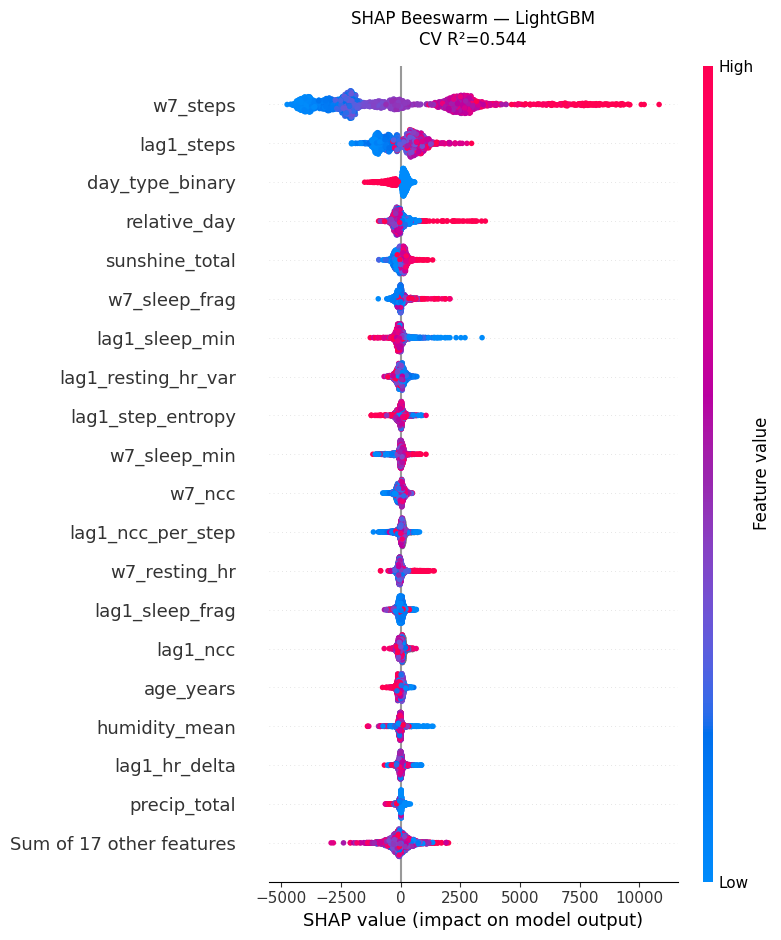

Saved: sp_shap_beeswarm.png


In [57]:
# ── SHAP Explainer ────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_full)

# ── Verification: SHAP sum check ──────────────────────────────────────────────
_pred     = best_model.predict(X_full)
_shap_sum = shap_values.values.sum(axis=1) + shap_values.base_values
_max_err  = np.abs(_pred - _shap_sum).max()
print(f'SHAP sum check — max error: {_max_err:.4f} (should be near 0)')

# ── Beeswarm — top 20 features ────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — {winner}\nCV R²={best_r2:.3f}', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sp_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sp_shap_beeswarm.png')

In [49]:
# ── Feature-group SHAP importance (answers the research question) ─────────────
mean_abs = np.abs(shap_values.values).mean(axis=0)
feat_shap = pd.DataFrame({'feature': SELECTED_FEATS, 'mean_abs_shap': mean_abs})

def _group_shap(feat_shap_df, groups):
    rows = []
    for grp_name, cols in groups.items():
        total = feat_shap_df[feat_shap_df['feature'].isin(cols)]['mean_abs_shap'].sum()
        rows.append({'group': grp_name, 'sum_mean_abs_shap': total})
    return pd.DataFrame(rows).sort_values('sum_mean_abs_shap')

grp_shap = _group_shap(feat_shap, GROUPS)

fig = px.bar(
    grp_shap, x='sum_mean_abs_shap', y='group', orientation='h',
    title=f'Feature Group Importance — {winner}<br>'
          '<sup>Sum of mean |SHAP| per group · higher = greater contribution to step count variation</sup>',
    labels={'sum_mean_abs_shap': 'Sum of mean |SHAP| (steps)', 'group': 'Feature Group'},
    color='sum_mean_abs_shap', color_continuous_scale='Blues',
    height=400, width=720,
)
fig.update_layout(coloraxis_showscale=False, yaxis=dict(categoryorder='total ascending'))
fig.show()

print('\nFeature group SHAP breakdown:')
print(grp_shap.sort_values('sum_mean_abs_shap', ascending=False).to_string(index=False))


Feature group SHAP breakdown:
                 group  sum_mean_abs_shap
  Last-week physiology        3421.798746
  Yesterday physiology        1485.478018
Today external/context        1090.659151
      Study / temporal         265.238175
      Patient metadata         108.517154


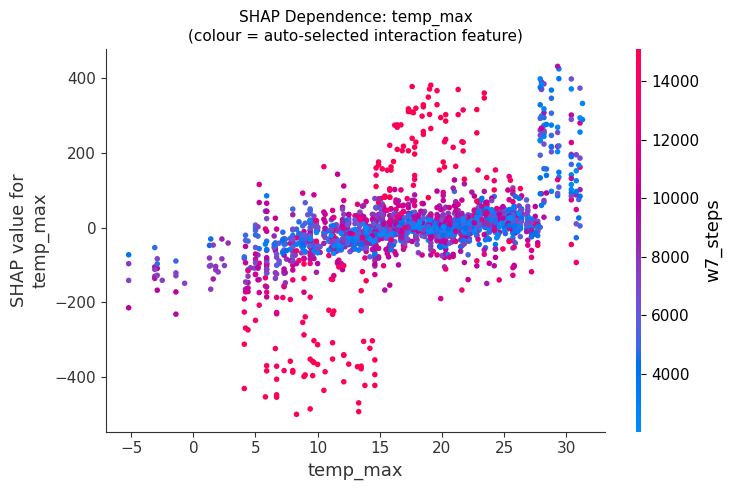

Saved: sp_shap_dep_temp_max.png


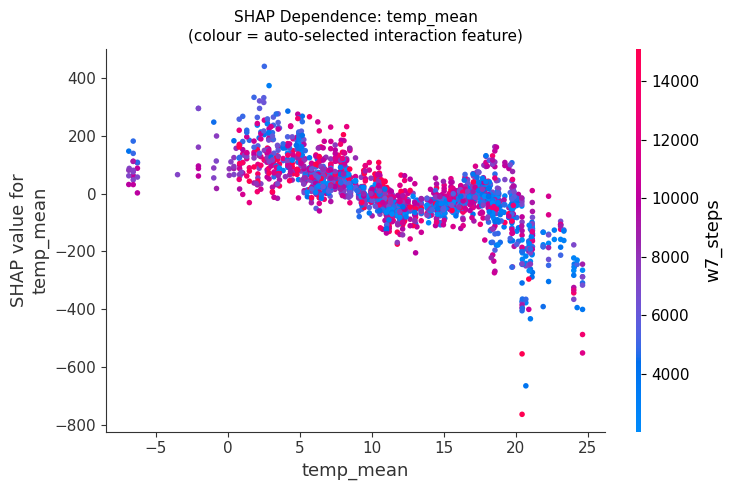

Saved: sp_shap_dep_temp_mean.png


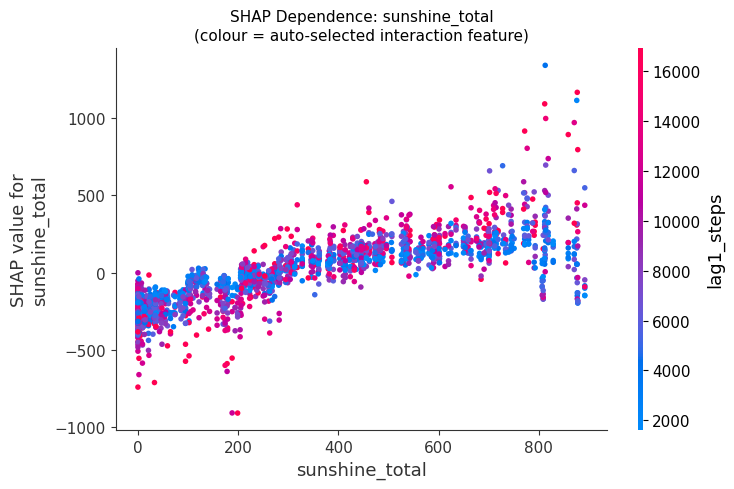

Saved: sp_shap_dep_sunshine_total.png


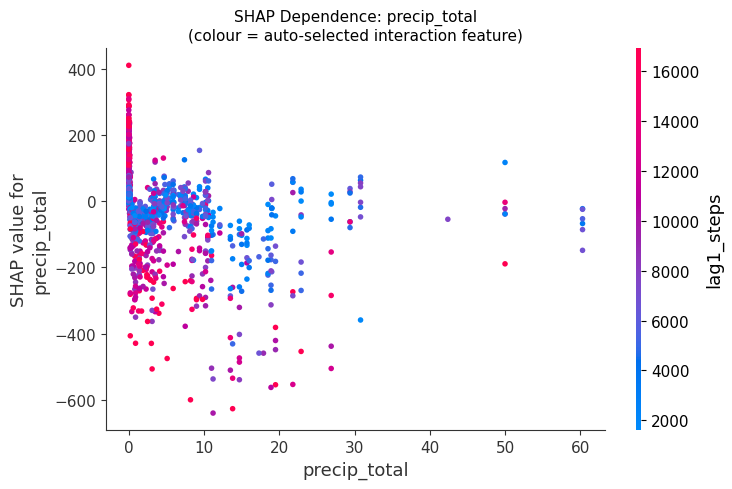

Saved: sp_shap_dep_precip_total.png


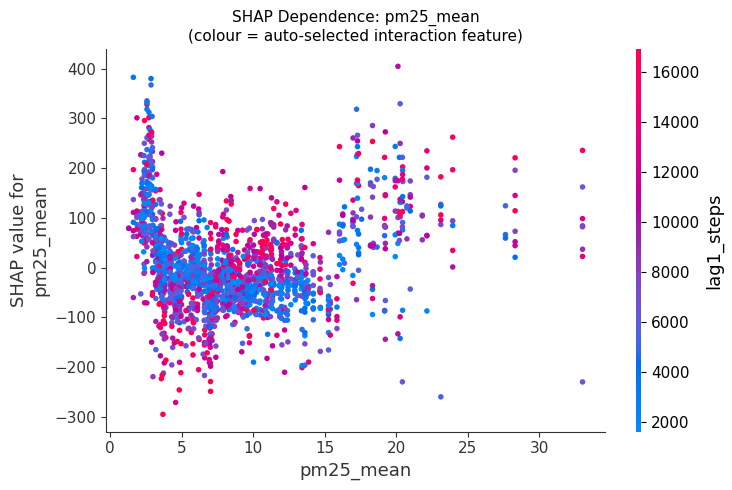

Saved: sp_shap_dep_pm25_mean.png


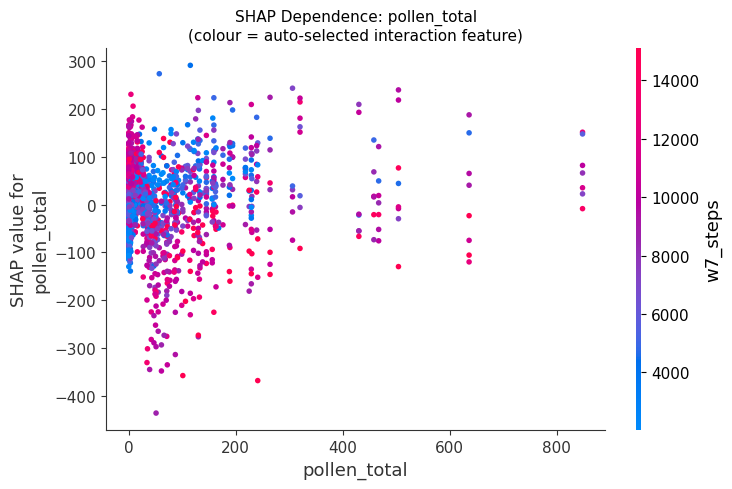

Saved: sp_shap_dep_pollen_total.png


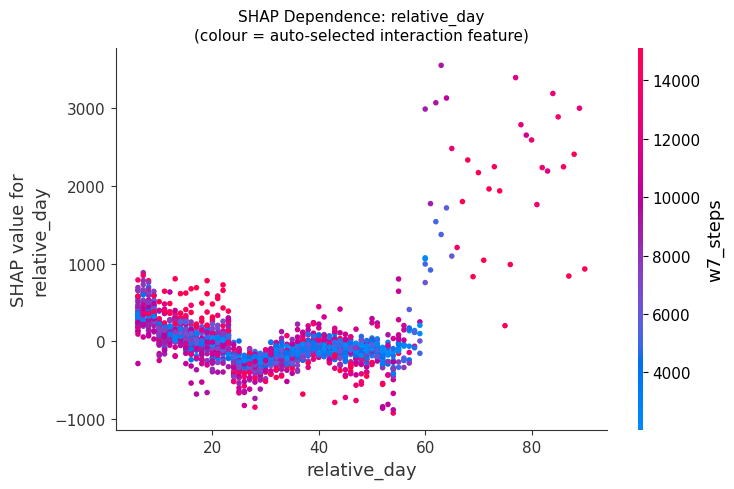

Saved: sp_shap_dep_relative_day.png


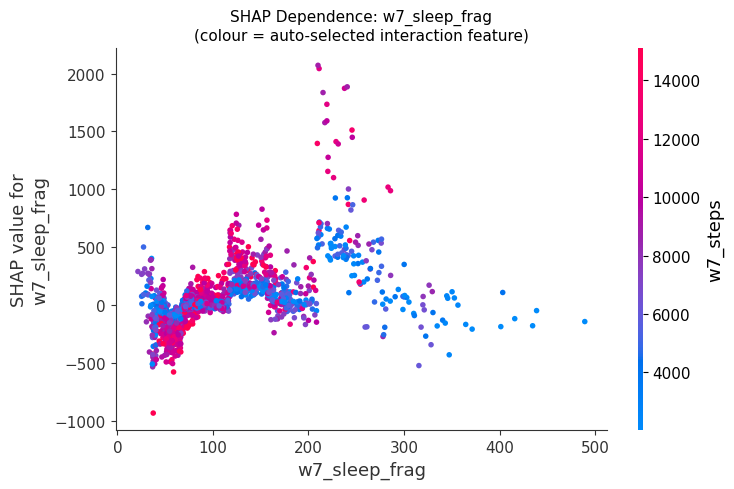

Saved: sp_shap_dep_w7_sleep_frag.png


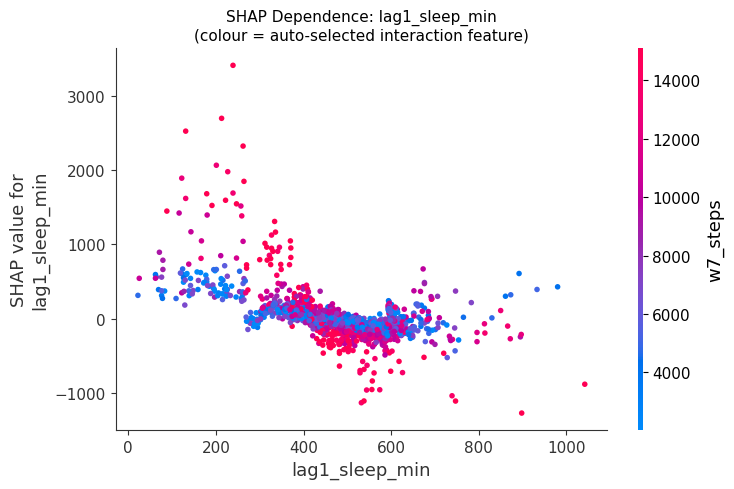

Saved: sp_shap_dep_lag1_sleep_min.png


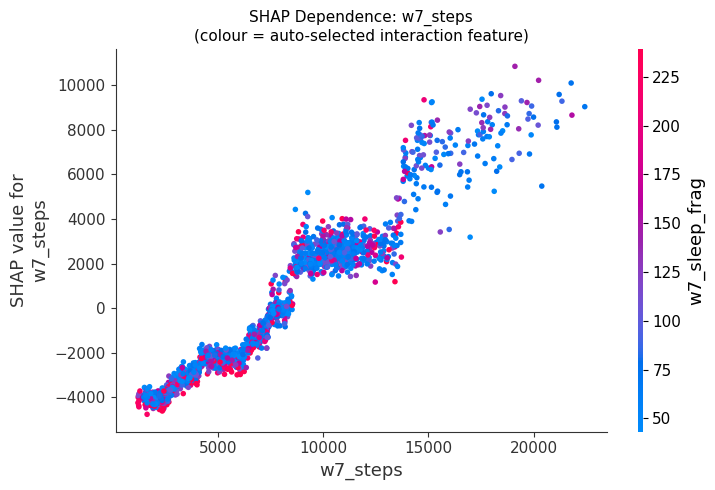

Saved: sp_shap_dep_w7_steps.png


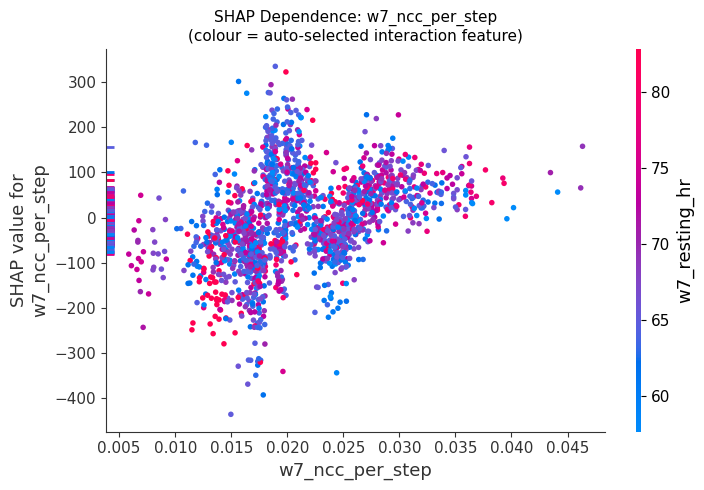

Saved: sp_shap_dep_w7_ncc_per_step.png


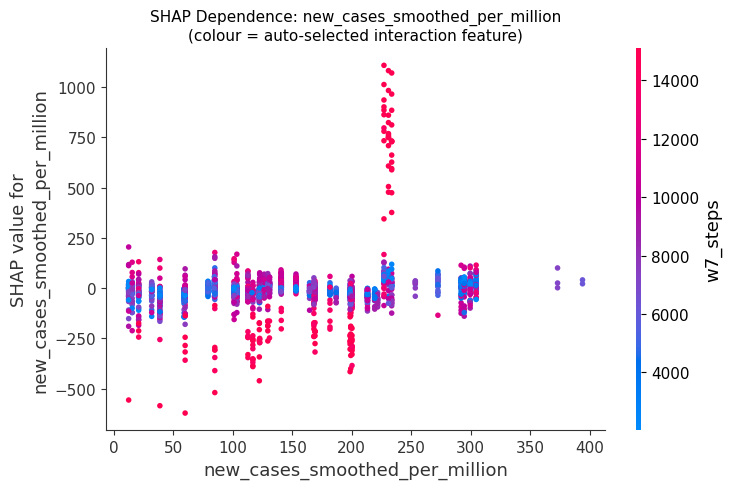

Saved: sp_shap_dep_new_cases_smoothed_per_million.png


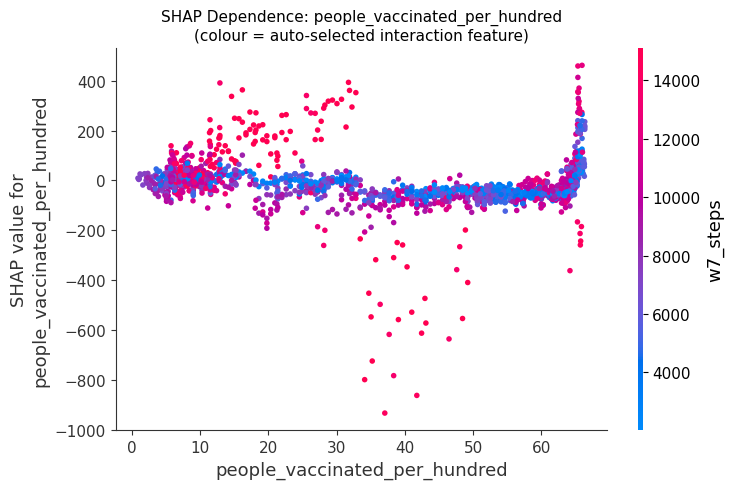

Saved: sp_shap_dep_people_vaccinated_per_hundred.png


In [51]:
# ── SHAP Dependence Plots — key external features ────────────────────────────
DEP_FEATURES = [
    'temp_max', 
    'temp_mean',
    'sunshine_total', 
    'precip_total',
    'pm25_mean',
    'pollen_total', 
    'relative_day',
    'w7_sleep_frag',
    'lag1_sleep_min',
    'w7_steps',
    'w7_ncc_per_step',
    'new_cases_smoothed_per_million',
    'people_vaccinated_per_hundred',
    ]

for feat in DEP_FEATURES:
    if feat not in SELECTED_FEATS:
        print(f'Skipping {feat}: not in SELECTED_FEATS')
        continue

    feat_idx = SELECTED_FEATS.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values.values,
        X_full.values,
        feature_names=SELECTED_FEATS,
        show=False,
    )
    plt.title(f'SHAP Dependence: {feat}\n(colour = auto-selected interaction feature)', fontsize=11)
    plt.tight_layout()
    fname = f'sp_shap_dep_{feat}.png'
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [21]:
def plot_dependence(feat, interaction_feat, alpha=0.5, figsize=(8, 5)):
    """SHAP dependence plot with a manually chosen interaction feature (colour).

    Parameters
    ----------
    feat : str
        Feature on the x-axis (must be in SELECTED_FEATS).
    interaction_feat : str
        Feature used for the colour axis (must be in SELECTED_FEATS).
    alpha : float
        Point opacity.
    figsize : tuple
        Figure size.

    Examples
    --------
    plot_dependence('sunshine_total', 'temp_max')
    plot_dependence('lag1_sleep_min', 'w7_steps')
    plot_dependence('stringency_index', 'day_type_binary')
    """
    if feat not in SELECTED_FEATS:
        raise ValueError(f'{feat!r} not in SELECTED_FEATS')
    if interaction_feat not in SELECTED_FEATS:
        raise ValueError(f'{interaction_feat!r} not in SELECTED_FEATS')

    feat_idx        = SELECTED_FEATS.index(feat)
    interaction_idx = SELECTED_FEATS.index(interaction_feat)

    plt.figure(figsize=figsize)
    shap.dependence_plot(
        feat_idx,
        shap_values.values,
        X_full.values,
        feature_names=SELECTED_FEATS,
        interaction_index=interaction_idx,
        alpha=alpha,
        show=False,
    )
    plt.title(f'SHAP Dependence: {feat}  |  colour = {interaction_feat}', fontsize=11)
    plt.tight_layout()
    plt.show()


<Figure size 800x500 with 0 Axes>

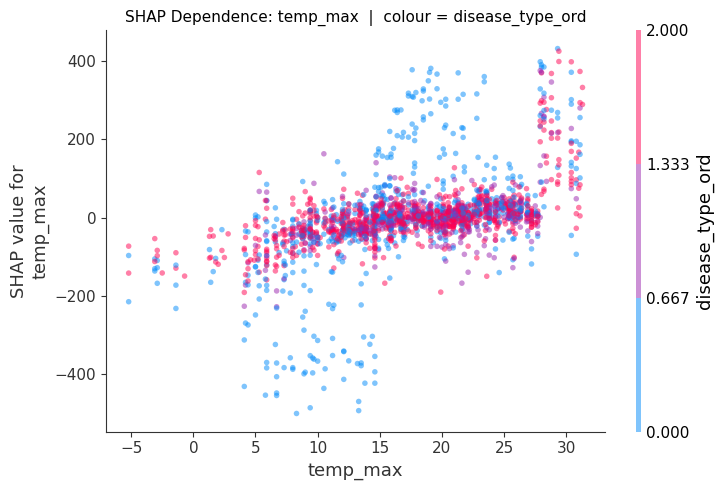

<Figure size 800x500 with 0 Axes>

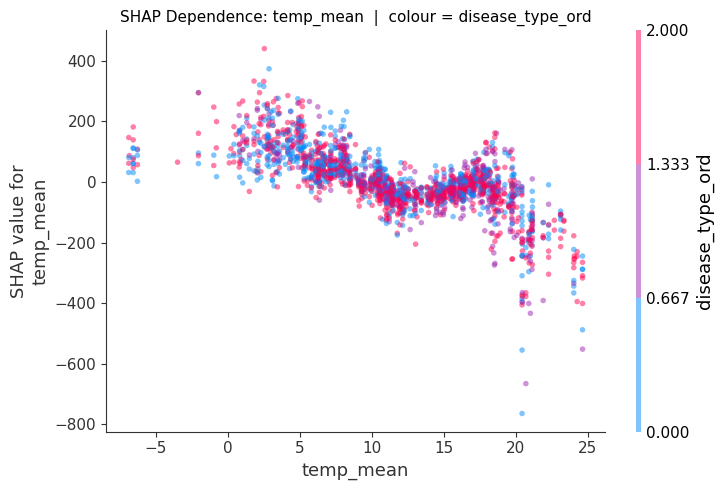

<Figure size 800x500 with 0 Axes>

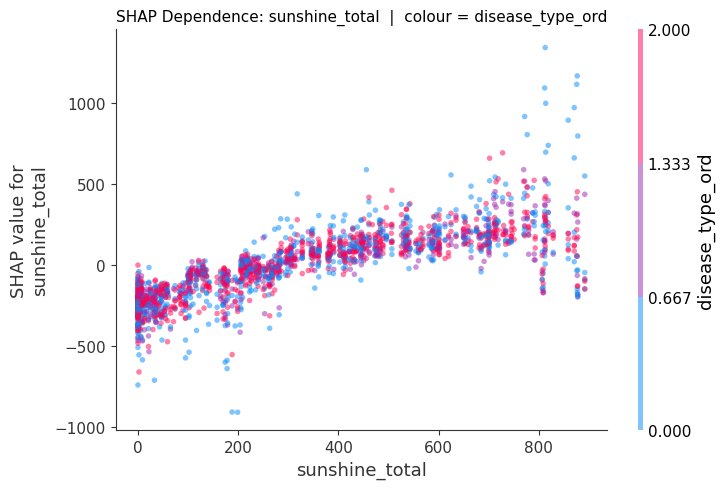

<Figure size 800x500 with 0 Axes>

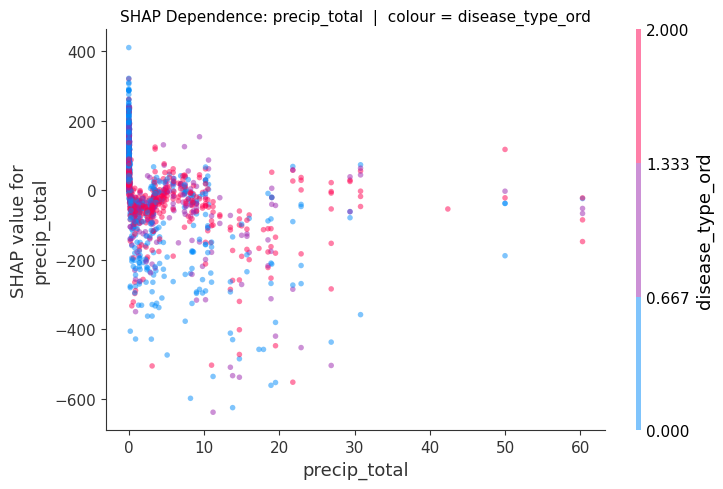

<Figure size 800x500 with 0 Axes>

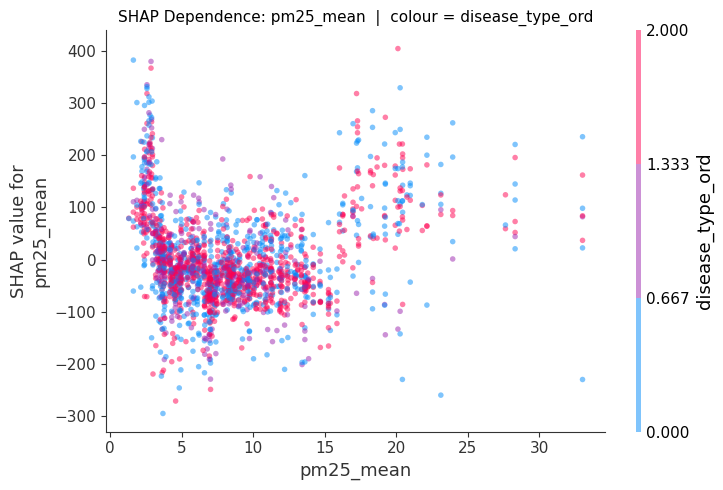

<Figure size 800x500 with 0 Axes>

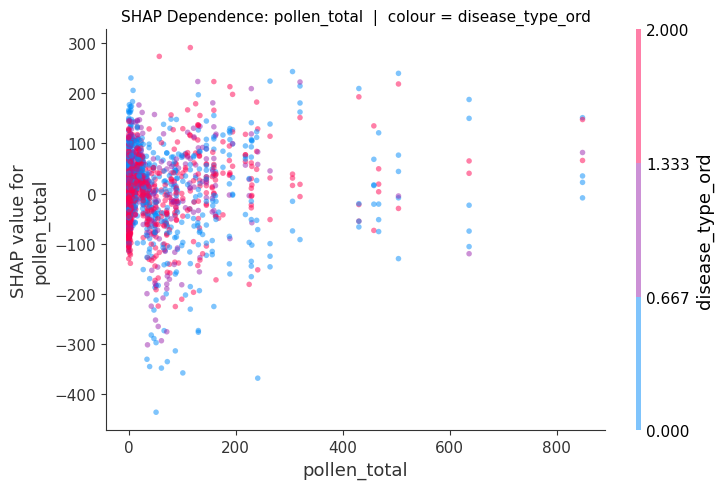

<Figure size 800x500 with 0 Axes>

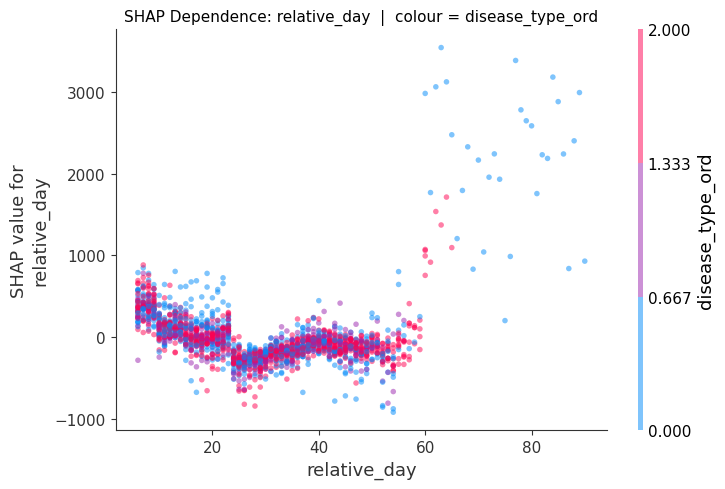

<Figure size 800x500 with 0 Axes>

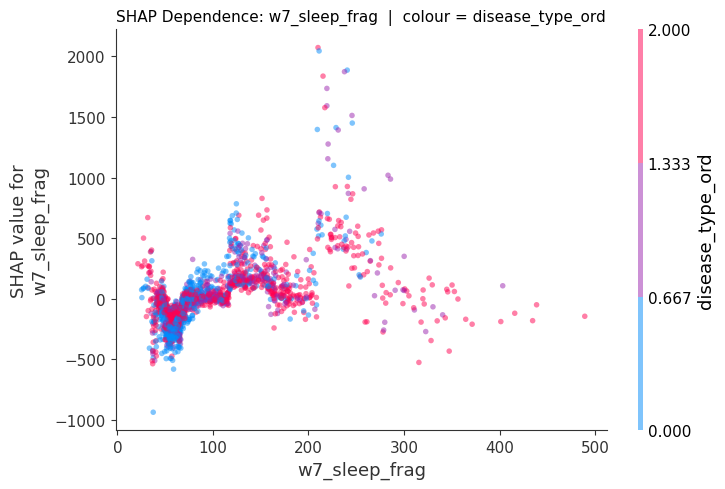

<Figure size 800x500 with 0 Axes>

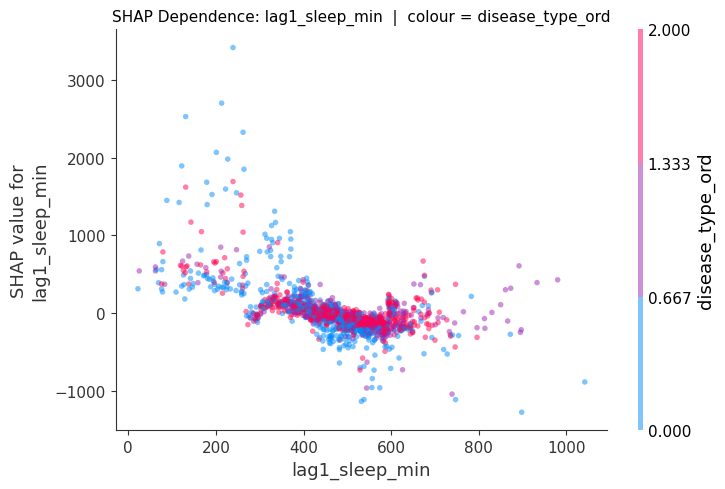

<Figure size 800x500 with 0 Axes>

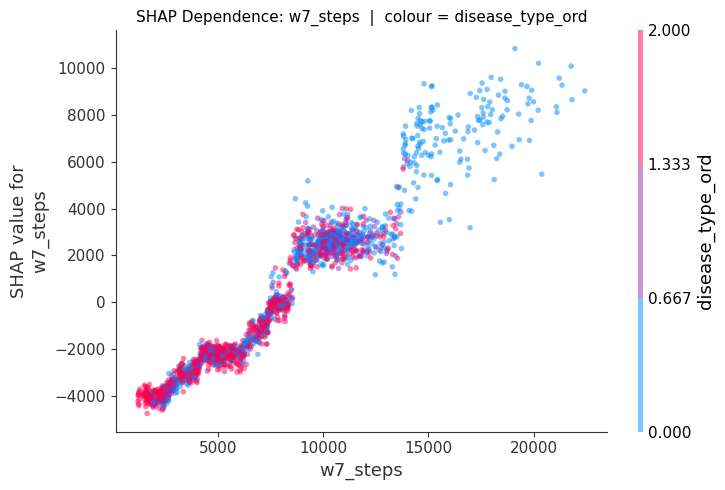

<Figure size 800x500 with 0 Axes>

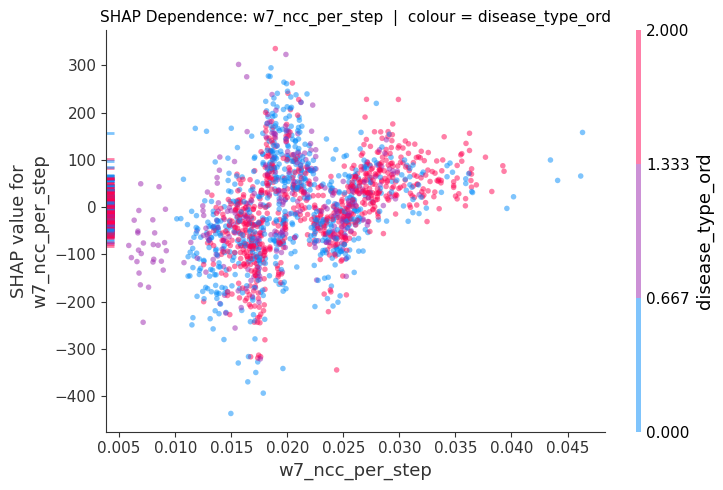

<Figure size 800x500 with 0 Axes>

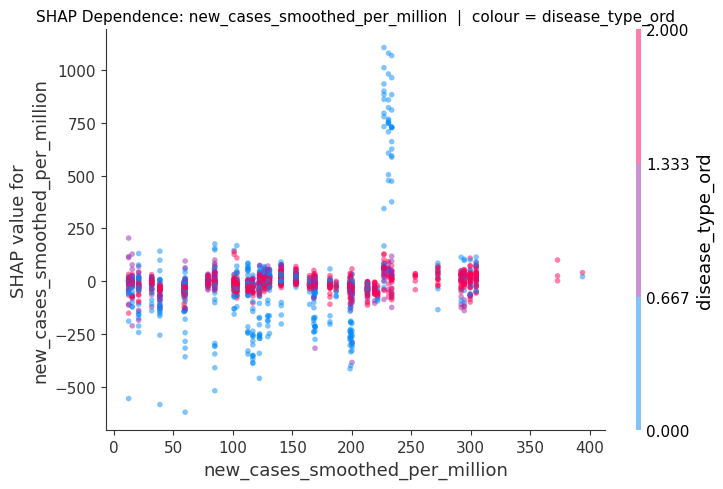

<Figure size 800x500 with 0 Axes>

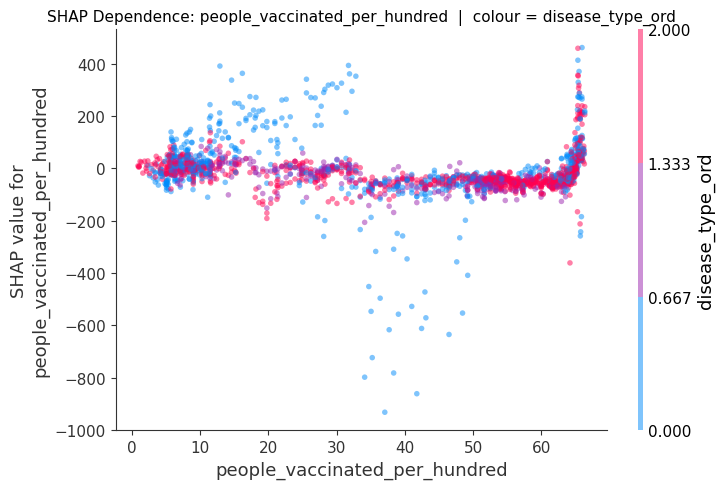

In [52]:
for feat in [
    'temp_max', 
    'temp_mean',
    'sunshine_total', 
    'precip_total',
    'pm25_mean',
    'pollen_total', 
    'relative_day',
    'w7_sleep_frag',
    'lag1_sleep_min',
    'w7_steps',
    'w7_ncc_per_step',
    'new_cases_smoothed_per_million',
    'people_vaccinated_per_hundred',
    ]:
    plot_dependence(feat, 'disease_type_ord')

In [61]:
# ── All features ranked by mean |SHAP| — ascending (least → most important) ───
feat_to_group = {f: g for g, fs in GROUPS.items() for f in fs}

ranked = feat_shap.copy().sort_values('mean_abs_shap', ascending=True).reset_index(drop=True)
ranked['group'] = ranked['feature'].map(feat_to_group).fillna('Other')

GROUP_COLORS = {
    'Yesterday physiology':   '#4C72B0',
    'Last-week physiology':   '#55A868',
    'Today external/context': '#C44E52',
    'Study / temporal':       '#8172B2',
    'Patient metadata':       '#937860',
}

fig = px.bar(
    ranked,
    x='mean_abs_shap', y='feature', orientation='h',
    color='group',
    color_discrete_map=GROUP_COLORS,
    title=f'All Features by Mean |SHAP| — {winner}'
          f'<br><span style="font-size:12px; color:gray">Sorted ascending — candidates for pruning are at the bottom</span>',
    labels={'mean_abs_shap': 'Mean |SHAP| (steps)', 'feature': 'Feature', 'group': 'Group'},
    height=max(600, len(ranked) * 22),
    width=820,
)
fig.update_layout(
    legend=dict(orientation='h', yanchor='top', y=-0.08, xanchor='left', x=0),
    margin=dict(b=100),
)
fig.update_yaxes(tickmode='linear', dtick=1, tickfont=dict(size=10))
fig.show()

print(f'\nAll features (ascending |SHAP|):')
print(ranked[['feature', 'group', 'mean_abs_shap']].to_string(index=False))


All features (ascending |SHAP|):
                       feature                  group  mean_abs_shap
                    sex_binary       Patient metadata       7.335324
              disease_type_ord       Patient metadata       8.745349
                     month_sin Today external/context      10.152806
              stringency_index Today external/context      11.241431
                 positive_rate Today external/context      11.275860
                     month_cos Today external/context      20.326576
                       dow_cos Today external/context      31.111906
                   study_phase       Study / temporal      34.034252
                       dow_sin Today external/context      44.169798
                  pollen_total Today external/context      54.665935
new_cases_smoothed_per_million Today external/context      59.581005
 people_vaccinated_per_hundred Today external/context      61.145102
                      temp_max Today external/context      61.507201


## Section 6 — External Context vs Daily Steps

Spearman correlation between today's step count (within-patient z-score) and same-day external factors, broken down by disease stage.  
Positive r = more steps on days with higher values of that factor.

In [26]:
from scipy.stats import spearmanr as _spearmanr

# ── Within-patient z-score of daily steps ────────────────────────────────────
def _zscore(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else pd.Series(0.0, index=x.index)

daily_model['steps_z'] = daily_model.groupby('id')['daily_steps'].transform(_zscore)

# Reconstruct disease_type string from ordinal (disease_type_ord is in FEATURE_COLS_A)
_disease_inv = {0: 'Early Disease Stage', 1: 'Fast Disease Progression', 2: 'Late Disease Stage'}
daily_model['disease_type_str'] = daily_model['disease_type_ord'].map(_disease_inv)

EXT_PAIRS = [
    ('temp_max',                       'Temp max (°C)'),
    ('temp_mean',                       'Temp mean (°C)'),
    ('sunshine_total',                 'Sunshine (min)'),
    ('precip_total',                   'Precipitation'),
    ('pm25_mean',                      'PM2.5'),
    ('pollen_total',                   'Pollen'),
    ('stringency_index',               'COVID stringency'),
    ('new_cases_smoothed_per_million', 'New cases/M'),
    ('people_vaccinated_per_hundred',  'Vaccinated (%)'),
    ('day_type_binary',                'Non-workday'),
    ('relative_day',                   'Study day'),
]
EXT_LABELS = [l for _, l in EXT_PAIRS]

# ── Per-disease-stage Spearman r ──────────────────────────────────────────────
records = []
for stage in DISEASE_ORDER:
    sub = daily_model[daily_model['disease_type_str'] == stage]
    for col, label in EXT_PAIRS:
        valid = sub[['steps_z', col]].dropna()
        r, p  = _spearmanr(valid['steps_z'], valid[col]) if len(valid) >= 10 else (np.nan, np.nan)
        records.append({'disease_type': stage, 'factor': label, 'r': r, 'p': p, 'n': len(valid)})

corr_ext = pd.DataFrame(records)
corr_ext['sig'] = corr_ext['p'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print(f'{"Disease Stage":<30}  {"Factor":<25}  {"r":>6}  {"p":>8}  {"":>4}  {"n":>5}')
print('-' * 85)
for _, row in corr_ext.iterrows():
    print(f'{str(row["disease_type"]):<30}  {row["factor"]:<25}  '
          f'{row["r"]:>+6.3f}  {row["p"]:>8.4f}  {row["sig"]:>4}  {row["n"]:>5}')

# ── Heatmap: disease stage × external factor ──────────────────────────────────
r_pivot   = corr_ext.pivot(index='disease_type', columns='factor', values='r').loc[DISEASE_ORDER, EXT_LABELS]
sig_pivot = corr_ext.pivot(index='disease_type', columns='factor', values='sig').loc[DISEASE_ORDER, EXT_LABELS]
text_matrix = [
    [f'{r:+.2f} {s}' for r, s in zip(r_row, s_row)]
    for r_row, s_row in zip(r_pivot.values, sig_pivot.values)
]

fig = px.imshow(
    r_pivot.values,
    x=EXT_LABELS, y=DISEASE_ORDER,
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0, range_color=[-0.5, 0.5],
    title='External Context vs Daily Steps (within-patient z) by Disease Stage<br>'
          '<sup>Spearman r · * p<0.05, ** p<0.01, *** p<0.001 · red = positive correlation</sup>',
    aspect='auto', height=310, width=1050,
)
for i, row_txt in enumerate(text_matrix):
    for j, txt in enumerate(row_txt):
        fig.add_annotation(x=j, y=i, text=txt, showarrow=False, font=dict(size=10, color='black'))
fig.update_layout(
    coloraxis_colorbar=dict(title='Spearman r'),
    xaxis=dict(tickangle=-30),
)
fig.show()

# ── Pooled bar chart (all patients, sorted by r) ──────────────────────────────
pool_records = []
for col, label in EXT_PAIRS:
    valid = daily_model[['steps_z', col]].dropna()
    r, p  = _spearmanr(valid['steps_z'], valid[col]) if len(valid) >= 10 else (np.nan, np.nan)
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    pool_records.append({'factor': label, 'r': r, 'p': p, 'sig': sig, 'n': len(valid)})

pool_df = pd.DataFrame(pool_records).sort_values('r', ascending=True)
pool_df['bar_label'] = pool_df.apply(
    lambda row: f'{row["factor"]} {row["sig"]}' if row['sig'] else row['factor'], axis=1
)

fig2 = go.Figure(go.Bar(
    x=pool_df['r'],
    y=pool_df['bar_label'],
    orientation='h',
    marker_color=pool_df['r'].apply(lambda r: '#C44E52' if r > 0 else '#4C72B0'),
    text=pool_df['r'].apply(lambda r: f'{r:+.3f}'),
    textposition='outside',
))
fig2.add_vline(x=0, line=dict(color='black', width=1))
fig2.update_layout(
    title='Pooled: External Context vs Daily Steps (z) — All Patients<br>'
          '<sup>Within-patient z-scores · sorted by r · * p<0.05, ** p<0.01, *** p<0.001</sup>',
    xaxis_title='Spearman r',
    xaxis=dict(range=[-0.65, 0.65]),
    height=420, width=680,
)
fig2.show()

Disease Stage                   Factor                          r         p            n
-------------------------------------------------------------------------------------
Early Disease Stage             Temp max (°C)              +0.098    0.0096    **    702
Early Disease Stage             Temp mean (°C)             +0.049    0.1943    ns    702
Early Disease Stage             Sunshine (min)             +0.165    0.0000   ***    702
Early Disease Stage             Precipitation              -0.098    0.0090    **    702
Early Disease Stage             PM2.5                      +0.060    0.1120    ns    702
Early Disease Stage             Pollen                     +0.117    0.0020    **    702
Early Disease Stage             COVID stringency           +0.021    0.5736    ns    702
Early Disease Stage             New cases/M                -0.001    0.9730    ns    702
Early Disease Stage             Vaccinated (%)             -0.050    0.1826    ns    702
Early Disease Stage     

In [27]:
# ── Per-patient heatmap — only pooled-significant factors ─────────────────────
# Determine which factors were significant in the pooled analysis
label_to_col = {label: col for col, label in EXT_PAIRS}

# Keep original EXT_PAIRS order (not pool_df's sorted-by-r order)
_ext_order = {label: i for i, (_, label) in enumerate(EXT_PAIRS)}
sig_df = (
    pool_df[pool_df['sig'] != ''][['factor', 'r', 'sig']]
    .copy()
    .assign(_order=lambda d: d['factor'].map(_ext_order))
    .sort_values('_order')
    .drop(columns='_order')
    .reset_index(drop=True)
)
sig_df['col'] = sig_df['factor'].map(label_to_col)

print(f'Pooled-significant factors (p < 0.05): {len(sig_df)}')
for _, sf in sig_df.iterrows():
    print(f'  {sf["factor"]:<25}  pooled r={sf["r"]:+.3f}  {sf["sig"]}')

if len(sig_df) == 0:
    print('No significant factors — skipping heatmap.')
else:
    # ── Per-patient Spearman r ────────────────────────────────────────────────
    rows_pat = []
    for pid in sorted(daily_model['id'].unique()):
        pat     = daily_model[daily_model['id'] == pid]
        disease = _disease_inv.get(int(pat['disease_type_ord'].iloc[0]), 'Unknown')
        row     = {'id': pid, 'disease_type': disease}
        for _, sf in sig_df.iterrows():
            sub = pat[['steps_z', sf['col']]].dropna()
            if len(sub) >= 10:
                r, p = _spearmanr(sub['steps_z'], sub[sf['col']])
            else:
                r, p = np.nan, np.nan
            row[f'r_{sf["col"]}']   = r
            row[f'sig_{sf["col"]}'] = '*' if (not np.isnan(p) and p < 0.05) else ''
        rows_pat.append(row)

    corr_pat = pd.DataFrame(rows_pat)
    corr_pat['disease_ord'] = corr_pat['disease_type'].map(
        {'Early Disease Stage': 0, 'Fast Disease Progression': 1, 'Late Disease Stage': 2}
    )
    # Sort by disease stage, then by r on the first significant factor (descending)
    first_r_col = f'r_{sig_df.iloc[0]["col"]}'
    corr_pat = corr_pat.sort_values(['disease_ord', first_r_col], ascending=[True, False])

    r_cols     = [f'r_{sf["col"]}'   for _, sf in sig_df.iterrows()]
    sig_m_cols = [f'sig_{sf["col"]}' for _, sf in sig_df.iterrows()]
    col_labels = sig_df['factor'].tolist()

    r_matrix   = corr_pat[r_cols].values
    sig_matrix = corr_pat[sig_m_cols].values
    y_labels   = [f'{row["id"]} ({row["disease_type"][:5]})' for _, row in corr_pat.iterrows()]

    fig = px.imshow(
        r_matrix, x=col_labels, y=y_labels,
        color_continuous_scale='RdBu_r',
        color_continuous_midpoint=0, range_color=[-1, 1],
        title='Per-Patient Spearman r: External Context vs Daily Steps (z)<br>'
              '<sup>Only pooled-significant factors · * individual p<0.05 · sorted by disease stage · red = positive</sup>',
        aspect='auto',
        height=max(500, len(corr_pat) * 20),
        width=max(550, 300 + len(sig_df) * 120),
    )
    for i in range(r_matrix.shape[0]):
        for j in range(r_matrix.shape[1]):
            if sig_matrix[i, j] == '*':
                fig.add_annotation(x=j, y=i, text='*', showarrow=False,
                                   font=dict(size=14, color='black'))
    fig.update_layout(coloraxis_colorbar=dict(title='Spearman r'))
    fig.update_yaxes(tickmode='linear', dtick=1, tickfont=dict(size=9))
    fig.show()

    print('\nMedian r across patients:')
    for _, sf in sig_df.iterrows():
        med   = corr_pat[f'r_{sf["col"]}'].median()
        n_sig = (corr_pat[f'sig_{sf["col"]}'] == '*').sum()
        print(f'  {sf["factor"]:<25}  median r={med:+.3f}  significant in {n_sig}/{len(corr_pat)} patients')

Pooled-significant factors (p < 0.05): 7
  Temp max (°C)              pooled r=+0.077  ***
  Sunshine (min)             pooled r=+0.132  ***
  Precipitation              pooled r=-0.070  **
  Pollen                     pooled r=+0.085  ***
  Vaccinated (%)             pooled r=-0.057  *
  Non-workday                pooled r=-0.167  ***
  Study day                  pooled r=-0.266  ***



Median r across patients:
  Temp max (°C)              median r=+0.070  significant in 15/43 patients
  Sunshine (min)             median r=+0.109  significant in 11/43 patients
  Precipitation              median r=-0.079  significant in 4/43 patients
  Pollen                     median r=+0.223  significant in 16/43 patients
  Vaccinated (%)             median r=-0.366  significant in 23/43 patients
  Non-workday                median r=-0.176  significant in 11/43 patients
  Study day                  median r=-0.366  significant in 23/43 patients


## Section 7 — Residual Analysis by Disease Stage

Re-run patient GroupKFold to collect **out-of-fold (OOF) predictions**, then compare:
- Per-disease-stage R² (is one group harder to predict?)
- Residual distributions (bias or spread differences?)
- Per-patient R² strip (which individual patients drive unexplained variance?)

In [56]:
# ── Disease stage colour map (consistent with other notebooks) ──────────────
DISEASE_COLORS = {
    'Early Disease Stage':    '#4C72B0',
    'Fast Disease Progression': '#DD8452',
    'Late Disease Stage':     '#55A868',
}

# ── OOF predictions via patient GroupKFold ────────────────────────────────────
gkf_oof = GroupKFold(n_splits=5)
oof_pred = np.full(len(y), np.nan)

for tr_idx, te_idx in gkf_oof.split(X_full, y, groups):
    X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_tr = y[tr_idx]
    if winner == 'LightGBM':
        _m = LGBMRegressor(**lgb_params).fit(X_tr, y_tr, categorical_feature=CAT_FEATURES)
    else:
        _m = CatBoostRegressor(**cat_params, cat_features=CAT_FEATURES).fit(X_tr, y_tr)
    oof_pred[te_idx] = _m.predict(X_te)

oof_df = (
    daily_model[['id', 'disease_type_str', 'disease_type_ord', 'daily_steps']]
    .copy()
    .reset_index(drop=True)
)
oof_df['pred']      = oof_pred
oof_df['residual']  = oof_df['daily_steps'] - oof_df['pred']
oof_df['abs_error'] = oof_df['residual'].abs()
oof_df = oof_df.dropna(subset=['pred'])

# ── Per-disease-stage R², RMSE, MAE ──────────────────────────────────────────
def _stage_metrics(grp):
    return pd.Series({
        'R²':    r2_score(grp['daily_steps'], grp['pred']),
        'RMSE':  np.sqrt((grp['residual'] ** 2).mean()),
        'MAE':   grp['abs_error'].mean(),
        'n_days': len(grp),
    })

stage_metrics = (
    oof_df.groupby('disease_type_str', observed=True)
    .apply(_stage_metrics)
    .reindex(DISEASE_ORDER)
    .reset_index()
    .rename(columns={'disease_type_str': 'Disease Stage'})
)
print('Per-disease-stage OOF metrics:')
print(stage_metrics.round(3).to_string(index=False))

# ── Per-patient R² ───────────────────────────────────────────────────────────
pat_rows = []
for pid, grp in oof_df.groupby('id'):
    if len(grp) < 5:
        continue
    pat_rows.append({
        'id': pid,
        'disease_type_str': grp['disease_type_str'].iloc[0],
        'disease_type_ord': grp['disease_type_ord'].iloc[0],
        'r2':    r2_score(grp['daily_steps'], grp['pred']),
        'rmse':  np.sqrt((grp['residual'] ** 2).mean()),
        'n_days': len(grp),
    })
pat_oof = pd.DataFrame(pat_rows)

print('\nPer-patient R² by disease stage (median / min / max):')
print(
    pat_oof.groupby('disease_type_str')['r2']
    .agg(['median', 'min', 'max', 'count'])
    .reindex(DISEASE_ORDER)
    .round(3)
    .to_string()
)

# ── Plot 1: per-disease-stage R² bar ─────────────────────────────────────────
fig1 = px.bar(
    stage_metrics,
    x='Disease Stage', y='R²',
    color='Disease Stage',
    color_discrete_map=DISEASE_COLORS,
    category_orders={'Disease Stage': DISEASE_ORDER},
    title=f'OOF R² by Disease Stage — {winner}<br>'
          '<sup>Lower R² → more unexplained variance in that group</sup>',
    text='R²',
    height=420, width=620,
)
fig1.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig1.update_layout(showlegend=False, yaxis=dict(range=[0, 1.05]))
fig1.show()

# ── Plot 2: residual violin by disease stage ──────────────────────────────────
fig2 = px.violin(
    oof_df,
    x='disease_type_str', y='residual',
    color='disease_type_str',
    color_discrete_map=DISEASE_COLORS,
    category_orders={'disease_type_str': DISEASE_ORDER},
    box=True, points='outliers',
    title=f'OOF Residual Distribution by Disease Stage — {winner}<br>'
          '<sup>Wider spread or bias away from 0 = harder to predict</sup>',
    labels={
        'disease_type_str': 'Disease Stage',
        'residual': 'Residual (actual − predicted steps)',
    },
    height=500, width=720,
)
fig2.add_hline(y=0, line_dash='dash', line_color='gray', annotation_text='0')
fig2.update_layout(showlegend=False)
fig2.show()

# ── Plot 3: per-patient R² strip by disease stage ────────────────────────────
fig3 = px.strip(
    pat_oof,
    x='disease_type_str', y='r2',
    color='disease_type_str',
    color_discrete_map=DISEASE_COLORS,
    category_orders={'disease_type_str': DISEASE_ORDER},
    hover_data=['id', 'n_days', 'rmse'],
    title=f'Per-patient OOF R² by Disease Stage — {winner}<br>'
          '<sup>Points below 0 = model does worse than predicting the mean</sup>',
    labels={'disease_type_str': 'Disease Stage', 'r2': 'Per-patient R²'},
    height=480, width=650,
)
fig3.add_hline(y=0, line_dash='dash', line_color='gray', annotation_text='R²=0 (mean baseline)')
fig3.update_layout(showlegend=False)
fig3.show()

Per-disease-stage OOF metrics:
           Disease Stage    R²     RMSE      MAE  n_days
     Early Disease Stage 0.512 3969.001 2806.473   702.0
Fast Disease Progression 0.412 3386.597 2400.282   321.0
      Late Disease Stage 0.490 2551.364 1775.499   914.0

Per-patient R² by disease stage (median / min / max):
                          median    min    max  count
disease_type_str                                     
Early Disease Stage       -0.110 -0.792  0.384     16
Fast Disease Progression  -0.290 -1.073  0.147      7
Late Disease Stage        -0.065 -3.619  0.581     19
